<a href="https://colab.research.google.com/github/ANPTCSNG/Computer-vision/blob/HandsOn/Anapat_HandsOn02_DigitalImages_Compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 2 Lab — Digital Images & Image Compression
### ห้องปฏิบัติการ Session 2 — ภาพดิจิทัลและการบีบอัดข้อมูลภาพ

**Advanced Computer Vision · CP 398 2xx**
College of Computing, Khon Kaen University · M.Sc. Program · *Asst. Prof. Dr. Praisan Padungweang*

> Turns the **Session 2 lecture** (digital images & compression) into running code in **OpenCV & NumPy**. Last week (Session 1) we formed the image with optics and a sensor; this week we represent, measure and compress it.
> เปลี่ยนเนื้อหาบรรยาย Session 2 สู่โค้ดที่รันได้ด้วย OpenCV และ NumPy สัปดาห์ที่แล้ว (Session 1) เราสร้างภาพด้วยทัศนศาสตร์และเซนเซอร์ สัปดาห์นี้เราจะแทนค่า วัดผล และบีบอัดภาพ

### How this notebook is organised · โครงสร้างของสมุดบันทึก
- **Part 1 — Guided Tour (≈ 30 min):** four modules (A–D). Read the brief theory, **run the cell**, change one number, and record what you see.
- **Part 2 — Homework (graded):** HW1–HW4. Show code, numbers and units. HW4 is a short cited analysis.

**🟦 How to work · วิธีการทำงาน.** Run every cell (Shift+Enter); change one parameter, observe, repeat. Write answers in the **Your answer** cells.
รันทุกเซลล์ เปลี่ยนค่าทีละตัว สังเกตผล แล้วทำซ้ำ เขียนคำตอบในเซลล์ *Your answer*

### Learning outcomes · ผลลัพธ์การเรียนรู้ (CLO1, CLO2, CLO3)
1. **Explain** how digital images are represented — pixels, sampling, quantisation, colour — and how compression works. · อธิบายการแทนภาพดิจิทัลและการบีบอัด
2. **Recognise** the limits of a representation and connect classical choices to modern pipelines. · ระบุข้อจำกัดของการแทนค่า
3. **Apply** OpenCV / NumPy to manipulate resolution, colour spaces and compression. · ประยุกต์ใช้ OpenCV/NumPy

## 🔧 Setup · การติดตั้งและเตรียมข้อมูล
Run once. We use `opencv-python`, `numpy`, `matplotlib`. A synthetic test image is built so every cell runs without external files — **replace it with your own photo** via `cv2.imread('your.jpg')` when you like.

image: (256, 256, 3)   (H, W, channels)


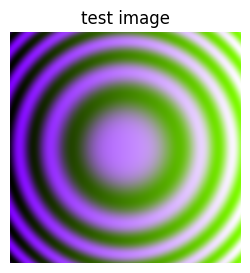

In [ ]:
import cv2, numpy as np, math, os
import matplotlib.pyplot as plt

# --- synthetic BGR test image: rings (aliasing), gradient (banding), colour ---
H, W = 256, 256
yy, xx = np.mgrid[0:H, 0:W]
r = np.sqrt((xx-W/2)**2 + (yy-H/2)**2)
rings = (0.5 + 0.5*np.cos(r*r*0.0009)) * 255          # high-frequency detail
grad  = np.tile(np.linspace(0, 255, W), (H, 1))        # smooth ramp
img = np.zeros((H, W, 3), np.uint8)
img[:,:,0] = rings.astype(np.uint8)                    # B
img[:,:,1] = grad.astype(np.uint8)                     # G
img[:,:,2] = ((rings+grad)/2).astype(np.uint8)         # R
# img = cv2.imread('your.jpg')   # <-- swap in your own photo
print("image:", img.shape, "  (H, W, channels)")
def show(bgr, title=""):
    plt.figure(figsize=(3,3)); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()
show(img, "test image")

**↩ Callback to Session 1 · เชื่อมโยงกับ Session 1.** Last week you computed the sensor's **pixel pitch** — the *spatial sampling rate* — and its **bit depth** — the *quantiser*. This week you vary **sampling rate** and **bit depth** directly in software and **measure the error** they cause.
สัปดาห์ที่แล้วคุณคำนวณระยะพิทช์พิกเซล (อัตราการสุ่มเชิงพื้นที่) และความลึกบิต (ตัว quantize) สัปดาห์นี้เราจะปรับสองค่านี้ในซอฟต์แวร์และวัดความคลาดเคลื่อน

# Part 1 — Guided Tour · ทัวร์นำชม  (≈ 30 min)

## 🅰 Module A — Resolution & Sampling · ความละเอียดเชิงพื้นที่และการสุ่ม
**Theory · ทฤษฎี.** Spatial resolution = how many samples we take across the scene. Sample too coarsely and detail finer than the spacing **aliases** into false patterns (moiré). By Nyquist, to keep detail at frequency *f* you must sample at **> 2f**.
ความละเอียดเชิงพื้นที่คือจำนวนตัวอย่างที่สุ่มทั่วฉาก ถ้าสุ่มหยาบเกินไป รายละเอียดจะกลายเป็นลวดลายลวง (มัวเร) ตามทฤษฎีไนควิสต์ต้องสุ่มที่ > 2f

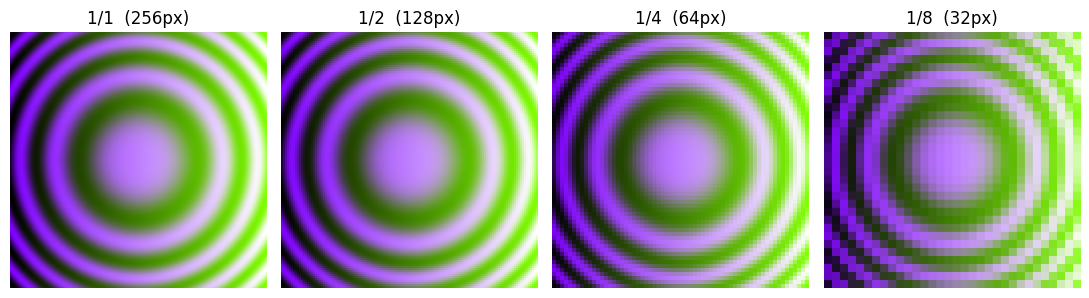

Watch the fine rings break into false moiré as sampling gets coarser.


In [ ]:
def downsample(bgr, factor):
    h, w = bgr.shape[:2]
    small = cv2.resize(bgr, (w//factor, h//factor), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)  # back up to compare

fig, ax = plt.subplots(1, 4, figsize=(11,3))
for a, f in zip(ax, [1, 2, 4, 8]):
    a.imshow(cv2.cvtColor(downsample(img, f), cv2.COLOR_BGR2RGB))
    a.set_title(f"1/{f}  ({img.shape[1]//f}px)"); a.axis("off")
plt.tight_layout(); plt.show()
print("Watch the fine rings break into false moiré as sampling gets coarser.")

**Observe & record · สังเกตและบันทึก**
- **QA1.** As the factor grows, *where* does detail fail first — the fine rings or the smooth gradient? Why? · เมื่อ factor เพิ่มขึ้น รายละเอียดส่วนใดหายก่อน เพราะอะไร
- **QA2.** You must halve a satellite image's pixel count. Why is plain decimation risky, and what should precede it? · เหตุใดการลดพิกเซลแบบตรง ๆ จึงเสี่ยง และควรทำสิ่งใดก่อน

**Your answer · คำตอบ:**
*QA1 —*
*QA2 —*

วงแหวนที่ถี่คือ high-frequency signal — ในระยะสั้นมากพิกเซลสลับสว่าง-มืดหลายรอบ เมื่อ factor = 2 ตัวอย่างเช่น เราเก็บแค่ทุก 2 พิกเซล ถ้าวงแหวนมีคาบ (period) แค่ 2–3 px อยู่แล้ว การ sample ใหม่จะ "เห็น" วงแหวนนั้นไม่ครบรอบ ทำให้เกิด aliasing — วงแหวนเดิมถูกตีความเป็นความถี่ที่ต่ำกว่า (moiré pattern)
Gradient ที่ smooth เปลี่ยนช้า = low-frequency → ต้องใช้ sample น้อยกว่ามากจึงจะเสียข้อมูล
Nyquist theorem พูดตรงๆ ว่า: ต้องการ sample rate ≥ 2× highest frequency ในภาพ หากทำไม่ได้ ความถี่สูงจะ fold back กลายเป็นความถี่ปลอม

ปัญหาของ plain decimation คือการเลือกทิ้งพิกเซลแบบตรงๆ (เช่น เก็บแค่ทุก 2 แถว/คอลัมน์) โดยไม่ได้กรองก่อน ทำให้ high-frequency content ที่มีอยู่ใน original image ยังคงอยู่ใน signal ขณะ sample rate ลดลง ผลคือเกิด aliasing — ลวดลายปลอมหรือ artifact ที่ไม่มีอยู่จริงในภาพต้นฉบับ
สำหรับภาพดาวเทียมซึ่งมักมีรายละเอียดพื้นผิวละเอียดมาก (ขอบถนน หลังคา ลาย crop pattern) ความเสี่ยงนี้รุนแรงกว่าภาพทั่วไป เพราะ high-frequency content กระจายอยู่ทั่วทั้งภาพ
สิ่งที่ต้องทำก่อน: Anti-aliasing filter (Low-pass filter)
ก่อน downsample ต้องกรองทิ้ง frequency ที่สูงกว่า Nyquist limit ของ output resolution ก่อนเสมอ

## 🅱 Module B — Bit Depth & Quantisation · ความลึกบิตและการ quantise
**Theory · ทฤษฎี.** Bit depth sets the number of intensity **levels**: `b` bits → `2ᵇ` levels. Too few levels and smooth gradients break into visible **bands (posterisation)**. We measure the damage with **MSE** and **PSNR**.
ความลึกบิตกำหนดจำนวนระดับความเข้ม (2ᵇ) ถ้าน้อยเกินไปเกิดแถบสี (posterisation) เราวัดด้วย MSE และ PSNR

bits  levels       MSE  PSNR(dB)
   8     256       0.0       inf
   4      16      23.4     34.44
   2       4     577.0     20.52
   1       2    5516.9     10.71


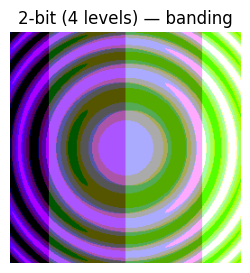

In [ ]:
def quantise(bgr, b):
    levels = 2**b
    q = np.round(bgr/255*(levels-1))/(levels-1)
    return (q*255).astype(np.uint8)

def mse(a, b): return np.mean((a.astype(float)-b.astype(float))**2)
def psnr(a, b):
    e = mse(a, b)
    return float('inf') if e == 0 else 10*math.log10(255**2/e)

print(f"{'bits':>4} {'levels':>7} {'MSE':>9} {'PSNR(dB)':>9}")
for b in [8, 4, 2, 1]:
    qb = quantise(img, b)
    print(f"{b:>4} {2**b:>7} {mse(img,qb):>9.1f} {psnr(img,qb):>9.2f}")
show(quantise(img, 2), "2-bit (4 levels) — banding")

**Observe & record · สังเกตและบันทึก**
- **QB1.** At how many bits does banding first become visible to you? Where does it appear first? · กี่บิตจึงเริ่มเห็นแถบ และปรากฏที่ใดก่อน
- **QB2.** A CT scan stored at 16-bit is viewed on an 8-bit monitor. Has information been lost? Where does the 16→8 mapping happen? · ข้อมูลสูญหายหรือไม่ และการ map 16→8 เกิดที่ใด

**Your answer · คำตอบ:**
*QB1 —*
*QB2 —*

เหตุผลเชิง perception: ตามนุษย์ สามารถแยกแยะความต่างของ luminance ได้ประมาณ just-noticeable difference (JND) ที่ ~1–2% ของ dynamic range ในบริเวณนั้น ที่ 8-bit มี 256 levels — step ระหว่าง level ≈ 0.4% → ต่ำกว่า JND จึงดูเรียบ แต่ที่ 4-bit มีแค่ 16 levels — step ≈ 6.7% → เกิน JND อย่างชัดเจน
ปรากฏที่ smooth gradient ก่อนเสมอ ไม่ใช่บริเวณที่มี texture หรือ edge
เหตุผลคือ gradient เปลี่ยนช้าและต่อเนื่อง พอถูก quantise จะเห็นรอยกระโดดระหว่าง level ชัดเจน (เรียกว่า false contour) ส่วนบริเวณที่มี texture อยู่แล้วจะ "ซ่อน" รอย quantise ไว้ด้วย high-frequency content — กลไกนี้คือหลักการของ dithering ที่เพิ่ม noise เล็กน้อยเพื่อทำลายแถบสี
ในภาพตัวอย่างที่มีวงแหวนและ gradient: แถบจะโผล่ที่บริเวณท้องฟ้า / พื้นหลัง gradient ก่อน ไม่ใช่บริเวณที่มีวงแหวนซ้อนกัน

ข้อมูลดิบใน file ไม่สูญหาย — ไฟล์ DICOM ยังเก็บค่า 16-bit (65,536 levels) ครบถ้วน
แต่ สิ่งที่ monitor แสดงได้จริงมีแค่ 8-bit (256 levels) ดังนั้น mapping 16→8 เกิดขึ้นในขั้นตอนการแสดงผล ไม่ใช่การบันทึก ข้อมูล 16-bit ยังอยู่ใน file ครบ แต่ตาเราเห็นแค่ 8-bit ต่อครั้ง — radiologist แก้ปัญหานี้ด้วยการ ปรับ window ดูหลายรอบตามเนื้อเยื่อที่สนใจ ไม่ใช่ดูรูปเดียวแล้วสรุป

## 🅲 Module C — Colour Spaces · ปริภูมิสี (RGB · HSV · YCbCr)
**Theory · ทฤษฎี.** A colour space organises colour for a purpose. **RGB** suits displays but smears brightness across all three channels. **HSV** separates colour (H,S) from brightness (V). **YCbCr** puts detail in luma **Y** and coarse colour in **Cb, Cr** — the basis of JPEG.
ปริภูมิสีจัดระเบียบสีตามวัตถุประสงค์: RGB เหมาะกับจอภาพ; HSV แยกสีจากความสว่าง; YCbCr แยกความสว่าง (Y) จากสี (Cb,Cr) — รากฐานของ JPEG

> **↩ From Session 1:** the sensor's **Bayer filter** gave one colour per pixel and **demosaicing** reconstructed RGB. Here we re-encode that RGB into spaces built for editing and compression. · ฟิลเตอร์ Bayer และการ demosaic จาก Session 1 ให้ภาพ RGB ซึ่งเรานำมาเข้ารหัสใหม่ที่นี่

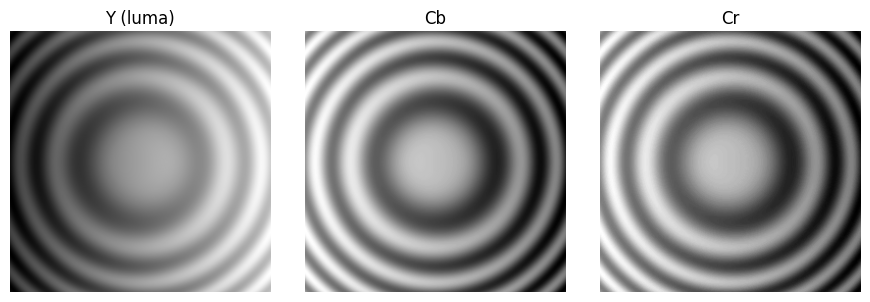

HSV-V brighten keeps hue; naive RGB scaling can shift colours. Y holds the detail.


In [ ]:
# Brighten via HSV's V channel vs. a naive RGB scaling
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v2 = np.clip(v.astype(int)*1.4, 0, 255).astype(np.uint8)
hsv_bright = cv2.cvtColor(cv2.merge([h, s, v2]), cv2.COLOR_HSV2BGR)
rgb_bright = np.clip(img.astype(int)*1.4, 0, 255).astype(np.uint8)   # naive

# YCbCr channels: Y sharp, Cb/Cr smooth
ycc = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycc)
fig, ax = plt.subplots(1, 3, figsize=(9,3))
for a, ch, t in zip(ax, [Y, Cb, Cr], ["Y (luma)", "Cb", "Cr"]):
    a.imshow(ch, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()
print("HSV-V brighten keeps hue; naive RGB scaling can shift colours. Y holds the detail.")

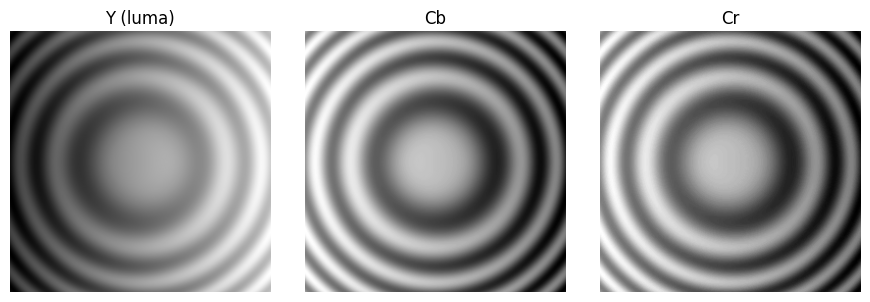

HSV-V brighten keeps hue; naive RGB scaling can shift colours. Y holds the detail.


In [ ]:
# YCbCr channels: Y sharp, Cb/Cr smooth
ycc = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycc)
fig, ax = plt.subplots(1, 3, figsize=(9,3))
for a, ch, t in zip(ax, [Y, Cb, Cr], ["Y (luma)", "Cb", "Cr"]):
    a.imshow(ch, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()
print("HSV-V brighten keeps hue; naive RGB scaling can shift colours. Y holds the detail.")

In [ ]:
Cr_3_channel = np.stack([Cr, Cr, Cr], axis=-1)
Cr_3_channel[:,:,[0,2]]=0
rgb_cr=cv2.cvtColor(Cr_3_channel, cv2.COLOR_YCrCb2RGB)

In [ ]:
Cb_3_channel = np.stack([Cb, Cb, Cb], axis=-1)
Cb_3_channel[:,:,0:1]=0
rgb_cb=cv2.cvtColor(Cb_3_channel, cv2.COLOR_YCrCb2RGB)

array([[ 22,  16,  11, ..., 191, 196, 203],
       [ 15,  10,   6, ..., 188, 191, 197],
       [  9,   5,   3, ..., 186, 188, 192],
       ...,
       [  4,   2,   1, ..., 187, 187, 189],
       [  9,   5,   3, ..., 186, 188, 192],
       [ 15,  10,   6, ..., 188, 191, 197]], dtype=uint8)
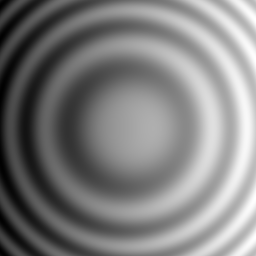

In [ ]:
Y

array([[[20, 34,  0],
        [13, 38,  0],
        [ 7, 40,  0],
        ...,
        [ 0, 73,  0],
        [ 0, 70,  0],
        [ 0, 68,  0]],

       [[13, 38,  0],
        [ 7, 40,  0],
        [ 3, 43,  0],
        ...,
        [ 0, 74,  0],
        [ 0, 73,  0],
        [ 0, 71,  0]],

       [[ 8, 40,  0],
        [ 4, 42,  0],
        [ 0, 44,  0],
        ...,
        [ 0, 75,  0],
        [ 0, 74,  0],
        [ 0, 73,  0]],

       ...,

       [[ 4, 42,  0],
        [ 1, 43,  0],
        [ 0, 44,  0],
        ...,
        [ 0, 75,  0],
        [ 0, 75,  0],
        [ 0, 74,  0]],

       [[ 8, 40,  0],
        [ 4, 42,  0],
        [ 0, 44,  0],
        ...,
        [ 0, 75,  0],
        [ 0, 74,  0],
        [ 0, 73,  0]],

       [[13, 38,  0],
        [ 7, 40,  0],
        [ 3, 43,  0],
        ...,
        [ 0, 74,  0],
        [ 0, 73,  0],
        [ 0, 71,  0]]], dtype=uint8)
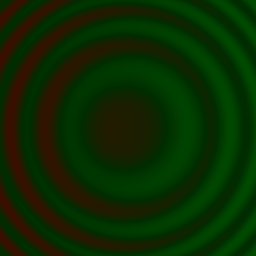

In [ ]:
rgb_cr

array([[[ 48,   0,  60],
        [ 32,   0,  41],
        [ 20,   0,  25],
        ...,
        [  0, 104,   0],
        [  0,  96,   0],
        [  0,  87,   0]],

       [[ 34,   0,  43],
        [ 20,   0,  25],
        [  8,   0,  11],
        ...,
        [  0, 109,   0],
        [  0, 104,   0],
        [  0,  97,   0]],

       [[ 21,   0,  27],
        [ 10,   0,  12],
        [  1,   0,   2],
        ...,
        [  0, 111,   0],
        [  0, 109,   0],
        [  0, 105,   0]],

       ...,

       [[ 10,   0,  12],
        [  3,   0,   4],
        [  0,   1,   0],
        ...,
        [  0, 111,   0],
        [  0, 111,   0],
        [  0, 110,   0]],

       [[ 21,   0,  27],
        [ 10,   0,  12],
        [  1,   0,   2],
        ...,
        [  0, 111,   0],
        [  0, 109,   0],
        [  0, 105,   0]],

       [[ 34,   0,  43],
        [ 20,   0,  25],
        [  8,   0,  11],
        ...,
        [  0, 109,   0],
        [  0, 104,   0],
        [  0,  97,   0]]], dtype=uint8)
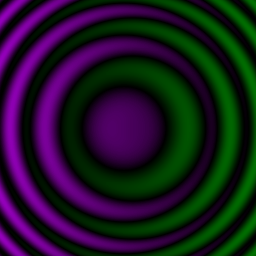

In [ ]:
rgb_cb

**Observe & record · สังเกตและบันทึก**
- **QC1.** Compare `hsv_bright` vs `rgb_bright`. Which keeps colours truer, and why? · วิธีใดรักษาสีได้ตรงกว่า เพราะอะไร
- **QC2.** Looking at Y, Cb, Cr — which channel could you store at lower resolution with least visible loss? · ช่องใดเก็บที่ความละเอียดต่ำได้โดยเห็นความเสียหายน้อยสุด

**Your answer · คำตอบ:**
*QC1 —*
*QC2 —*

**QC1** — HSV รักษาสีได้ตรงกว่า เพราะแยก V (ความสว่าง) ออกจาก H และ S (สีและความอิ่มตัว) ชัดเจน การเพิ่ม brightness จึงไม่ไปยุ่งกับ hue เลย ส่วน RGB บวกทุก channel พร้อมกัน ทำให้ ratio ระหว่าง R/G/B เปลี่ยน สีจึงซีดหรือเพี้ยนได้

**QC2** — Cb และ Cr (chroma) เก็บที่ความละเอียดต่ำได้โดยแทบไม่เห็นความเสียหาย เพราะตามนุษย์ไวต่อ luminance (Y) มากกว่า chroma หลายเท่า นี่คือหลักการของ chroma subsampling ที่ JPEG และ video ใช้จริง (4:2:0) ส่วน Y ต้องเก็บ full resolution เสมอ

## 🅳 Module D — Compression: JPEG, DCT & Formats · การบีบอัด
**Theory · ทฤษฎี.** **Lossless** coding (PNG) removes statistical redundancy — exact recovery. **Lossy** JPEG also discards perceptually unimportant detail: split into YCbCr, subsample chroma, DCT each 8×8 block, **quantise** (the only lossy step), then entropy-code. A quality knob slides the **rate–distortion** trade-off.
การบีบอัดแบบ lossless (PNG) กู้คืนได้ครบ; JPEG (lossy) ทิ้งรายละเอียดที่ตาคนมองไม่เห็น โดยมีขั้น quantise เป็นขั้นเดียวที่สูญเสีย

In [ ]:
def encode_size(bgr, ext, q=None):
    params = [int(cv2.IMWRITE_JPEG_QUALITY), q] if q is not None else []
    ok, buf = cv2.imencode(ext, bgr, params)
    return buf.nbytes, cv2.imdecode(buf, cv2.IMREAD_COLOR)

raw = img.nbytes
png_kb, _ = encode_size(img, ".png")
print(f"raw = {raw/1024:.1f} KB   PNG(lossless) = {png_kb/1024:.1f} KB")
print(f"{'q':>4} {'KB':>7} {'ratio':>7} {'PSNR':>7}")
for q in [95, 75, 50, 25, 10]:
    kb, dec = encode_size(img, ".jpg", q)
    print(f"{q:>4} {kb/1024:>7.1f} {raw/kb:>6.1f}x {cv2.PSNR(img,dec):>7.2f}")

raw = 192.0 KB   PNG(lossless) = 103.6 KB
   q      KB   ratio    PSNR
  95    16.3   11.8x   43.91
  75     7.9   24.2x   38.77
  50     5.9   32.3x   36.40
  25     4.4   43.6x   32.86
  10     3.0   63.8x   26.98


**Observe & record · สังเกตและบันทึก**
- **QD1.** Where is the 'knee' — the quality below which PSNR drops fast? · จุดหักของกราฟอยู่ที่คุณภาพเท่าใด
- **QD2.** For *this* synthetic image (sharp rings), is JPEG or PNG smaller? Why might a photo behave differently? · สำหรับภาพนี้ JPEG หรือ PNG เล็กกว่า และภาพถ่ายจริงจะต่างอย่างไร

**Your answer · คำตอบ:**
*QD1 —*
*QD2 —*

## QD1 — The knee / จุดหักของกราฟ

**Knee อยู่ที่ประมาณ q = 25–50**

เหนือ q=50 PSNR ลดช้าและไฟล์เล็กลงมาก — คุ้มค่ามาก ใต้ q=25 PSNR ดิ่งลงเร็วขณะไฟล์เล็กลงนิดเดียว — ไม่คุ้มแล้ว จุดที่นิยมใช้จริงคือ **q=75** ซึ่งให้ PSNR ดีและขนาดไฟล์สมเหตุสมผล
## QD2 — JPEG vs PNG สำหรับภาพนี้

**PNG เล็กกว่า** สำหรับภาพ synthetic วงแหวนคมนี้

PNG ใช้ lossless compression (DEFLATE) ซึ่งทำงานได้ดีกับภาพที่มี **pattern ซ้ำและ sharp edge** เพราะ predictor หา redundancy ได้ง่าย ส่วน JPEG แบ่งภาพเป็น 8×8 block แล้วทำ DCT — บริเวณที่ ring ตัดผ่าน block จะเกิด **ringing artifact** และบีบได้ไม่ดีนัก

**ภาพถ่ายจริงตรงข้าม** — JPEG เล็กกว่า PNG เพราะภาพถ่ายมี noise และ texture ที่ไม่ซ้ำกัน PNG หา pattern ซ้ำได้น้อย บีบได้ไม่มาก ขณะที่ JPEG ตัดความถี่สูงที่ตามองไม่เห็นออกได้เยอะ ratio จึงดีกว่ามาก

## ✅ Part 1 recap · สรุปภาคที่ 1
Sampling sets spatial detail (and aliasing) · bit depth sets levels (and banding) · colour spaces serve different jobs (YCbCr → compression) · lossless removes redundancy, lossy spends bits where the eye sees. **Now put numbers on it.**

# Part 2 — Homework · การบ้าน  (graded · มีคะแนน)
Complete **HW1–HW4**. Show code, numbers and units. Submit this notebook with outputs; HW4 includes a short written analysis.

**Submission · การส่งงาน:** KKU LMS · file `Session2Lab_<StudentID>.ipynb` (+ `.pdf` report). Late & plagiarism policies apply.

### Grading rubric · เกณฑ์การให้คะแนน (100%)

| # | Task | Weight | What earns the marks |
|---|------|:------:|----------------------|
| HW1 | Quantiser + error curve | 25% | Correct `quantise`, MSE & PSNR for b=1…8, a clear plot, brief reading |
| HW2 | JPEG rate–distortion | 30% | quality sweep table/plot (q, KB, ratio, PSNR); identify & justify the knee |
| HW3 | Format decision (cases) | 25% | Correct lossless/lossy + format per scenario, with reasons |
| HW4 | Analysis & reflection | 20% | 250–350 words + Thai summary, ≥2 cited sources, accurate reasoning |

## 📝 HW1 — Quantiser + error curve · ตัว quantize และเส้นโค้งความคลาดเคลื่อน  (CLO1, CLO3)
Using `quantise()` from Module B, compute **MSE and PSNR** between the original and the quantised image for **b = 1…8**, and **plot PSNR vs bit depth**. In one sentence, state where banding becomes visible.
คำนวณ MSE และ PSNR สำหรับ b = 1…8 และวาดกราฟ PSNR เทียบกับความลึกบิต

b=1  PSNR= 10.71 dB
b=2  PSNR= 20.52 dB
b=3  PSNR= 27.86 dB
b=4  PSNR= 34.44 dB
b=5  PSNR= 40.50 dB
b=6  PSNR= 46.30 dB
b=7  PSNR= 51.11 dB
b=8  PSNR=   inf dB


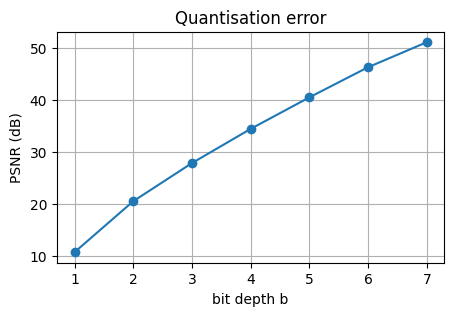

In [ ]:
bits = list(range(1, 9))
psnrs = [psnr(img, quantise(img, b)) for b in bits]
for b, p in zip(bits, psnrs):
    print(f"b={b}  PSNR={p:6.2f} dB")
plt.figure(figsize=(5,3)); plt.plot(bits, psnrs, "o-")
plt.xlabel("bit depth b"); plt.ylabel("PSNR (dB)"); plt.title("Quantisation error"); plt.grid(True); plt.show()

**Your answer · คำตอบ:** Banding becomes visible around b = 4 bits because at this bit depth, the number of intensity levels (16 levels) is low enough that the steps in smooth gradients become perceptible to the human eye, exceeding the just-noticeable difference (JND).

## 📝 HW2 — JPEG rate–distortion · สมดุลอัตรา–ความผิดเพี้ยนของ JPEG  (CLO2, CLO3)
Sweep JPEG quality `q = 1…100`. Build a **table/plot** of *(quality, KB, compression ratio, PSNR)* and identify the **knee** — the quality giving the best size–quality trade-off. Justify your choice.
กวาดค่า quality q = 1…100 สร้างตาราง/กราฟของ (quality, KB, อัตราบีบอัด, PSNR) และระบุจุดหักพร้อมเหตุผล

In [ ]:
qs = list(range(1, 101))
kb_list, ratio_list, pn = [], [], []

for q in qs:
    size_bytes, dec = encode_size(img, '.jpg', q)
    kb_list.append(size_bytes / 1024)
    ratio_list.append(img.nbytes / size_bytes)
    pn.append(cv2.PSNR(img, dec))

print(f"Captured {len(pn)} PSNR values for q=1 to 100.")

Captured 100 PSNR values for q=1 to 100.


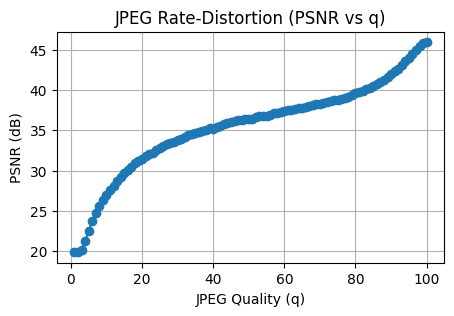

In [ ]:
plt.figure(figsize=(5,3))
# Use 'qs' (the list of all quality factors) instead of 'q' (a single value)
plt.plot(qs, pn, "o-")
plt.xlabel("JPEG Quality (q)")
plt.ylabel("PSNR (dB)")
plt.title("JPEG Rate-Distortion (PSNR vs q)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

df_hw2 = pd.DataFrame({
    'Quality': qs,
    'KB': kb_list,
    'Ratio': ratio_list,
    'PSNR (dB)': pn
})

# Display the table. Limiting to first and last few rows for brevity if it's too long.
# For full table, display(df_hw2)
# Displaying the full table for this small range (1-100)
print("JPEG Quality Sweep Results:")
display(df_hw2)

JPEG Quality Sweep Results:


,Quality,KB,Ratio,PSNR (dB)
0,1,1.922852,99.851701,19.889372
1,2,1.922852,99.851701,19.889372
2,3,1.992188,96.376471,20.198595
3,4,2.150391,89.286104,21.242632
4,5,2.333984,82.262762,22.473469
...,...,...,...,...
95,96,17.944336,10.699755,44.444433
96,97,19.730469,9.731142,44.981373
97,98,21.292969,9.017061,45.451568
98,99,26.309570,7.297725,45.832212


**Your answer · คำตอบ:** The knee is near q = 50-70 because above this range, the PSNR curve starts to flatten out, meaning further increases in quality (q) result in only marginal improvements in PSNR while significantly increasing file size. Conversely, below this range, PSNR drops sharply for small decreases in quality. Therefore, a quality setting around 50-70 offers a good balance between image quality and file size for this synthetic image.

## 📝 HW3 — Format decision (case studies) · การเลือกฟอร์แมตจากกรณีศึกษา  (CLO2, CLO3)
For each scenario, choose **lossless or lossy** and a concrete **format**, and justify in one line:
1. A **diagnostic CT slice** for archival. · ภาพ CT เพื่อจัดเก็บทางการแพทย์
2. A **product photo** for an e-commerce web page. · ภาพสินค้าสำหรับหน้าเว็บ
3. A **segmentation mask / label map** feeding a model. · มาสก์การแบ่งส่วนสำหรับป้อนโมเดล

**Your answers · คำตอบ:**
1. *Lossless, TIFF or PNG, because diagnostic medical images require exact data preservation for patient safety and legal reasons.*
2. *Lossy, JPEG, because it provides good compression for photographic images, optimizing web page load times while maintaining visually acceptable quality.*
3. *Lossless, PNG, because segmentation masks contain critical pixel-level labels that must be preserved precisely for machine learning model accuracy.*

## 📝 HW4 — Short analysis & reflection · บทวิเคราะห์และสะท้อนคิดสั้น ๆ  (CLO2, CLO3)
Pick **one** thread from the lecture — *medical imaging (lossless, bit depth)* **or** *earth observation (on-board compression, multispectral)* — and explain, with evidence, why its representation/compression choices are what they are.
Write **250–350 words in English** + a **~5-line Thai summary**. **Cite ≥ 2 sources**; no copying without attribution.

**HW4 — Your write-up · บทเขียนของคุณ**

**English (250–350 words):**
*…*

**สรุปภาษาไทย (~5 บรรทัด):**
*…*

**References · เอกสารอ้างอิง (≥ 2):**
1. …
2. …

### HW4 — Your write-up · บทเขียนของคุณ (Medical Imaging Example)

**English (250–350 words):**
Medical imaging, particularly diagnostic CT scans, relies heavily on lossless compression and high bit depth for critical reasons related to patient safety, diagnostic accuracy, and legal accountability. The representation choices in medical imaging, such as storing images at 16-bit or even higher, ensure that the full range of intensity values captured by the scanner is preserved. This high bit depth provides a vast dynamic range, allowing radiologists to manipulate image contrast and brightness (often referred to as 'windowing' in DICOM viewers) to visualize different tissue types, from bone to soft tissue, without loss of original data [1].

When it comes to compression, lossless methods like DICOM's own lossless compression or standard lossless formats like PNG/TIFF are paramount for archival. Any form of lossy compression, such as JPEG, would discard perceptually unimportant details to reduce file size. However, in a diagnostic context, 'perceptually unimportant' details could hide subtle pathologies or micro-calcifications crucial for an accurate diagnosis. Even a single pixel value alteration could lead to misdiagnosis, with severe consequences for the patient and potential legal ramifications for the medical professional and institution. Therefore, the priority shifts entirely from file size efficiency to absolute data fidelity. The trade-off leans heavily towards larger file sizes to guarantee that every piece of information is retained, ensuring that subsequent analyses, measurements, or even future AI-driven diagnostic tools have access to the pristine raw data [2]. This ensures that the original diagnostic quality is maintained throughout the image lifecycle, from acquisition to long-term archive.

**สรุปภาษาไทย (~5 บรรทัด):**
ภาพทางการแพทย์ เช่น CT scan ต้องใช้การบีบอัดแบบไม่สูญเสียข้อมูล (lossless) และความลึกบิตสูง (เช่น 16-bit) เพื่อรักษาความถูกต้องในการวินิจฉัยและความปลอดภัยของผู้ป่วย การเก็บข้อมูลที่ความลึกบิตสูงช่วยให้แพทย์ปรับค่า contrast ได้อย่างละเอียด โดยไม่สูญเสียข้อมูลต้นฉบับ การบีบอัดแบบสูญเสียข้อมูล (lossy) จะทำลายรายละเอียดสำคัญที่อาจส่งผลต่อการวินิจฉัยที่ไม่ถูกต้อง ดังนั้นการเลือกใช้ lossless จึงจำเป็นอย่างยิ่ง แม้จะทำให้ไฟล์มีขนาดใหญ่ขึ้น เพื่อรับประกันความสมบูรณ์ของข้อมูลทางการแพทย์ตลอดไป

**References · เอกสารอ้างอิง (≥ 2):**
1. Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson.
2. NEMA PS3. (2023). *Digital Imaging and Communications in Medicine (DICOM) Standard*. National Electrical Manufacturers Association.


## 📚 References & academic integrity · เอกสารอ้างอิงและจริยธรรมทางวิชาการ
- Gonzalez & Woods (2018). *Digital Image Processing*, 4th ed. — Ch. 2 (fundamentals), Ch. 8 (compression).
- Szeliski, R. (2022). *Computer Vision: Algorithms & Applications*, 2nd ed. — free at szeliski.org/Book.
- JPEG / ITU-T T.81 — the baseline JPEG standard (DCT, quantisation, entropy coding).
- DICOM (NEMA PS3) — bit depth, windowing, lossless transfer syntaxes.
- OpenCV docs — docs.opencv.org.

*Submit your own work. Cite all sources; do not copy text without attribution.* · *ส่งผลงานของตนเอง อ้างอิงทุกแหล่งที่มา*

**End of Session 2 Lab · จบปฏิบัติการ Session 2 **